In [4]:
import pandas as pd
import import_ipynb
import nbimporter
from utils import prepareTrainingSet3Sec,standardization,Grafico_Before_After_Standardization,Grafico_Tre_Valori,evaluate_Model, encode_labels, ConfusionMatrix# type: ignorefrom sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV  
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score
from sklearn.exceptions import ConvergenceWarning
import warnings


SENZA STANDARDIZZAZIONE

In [ ]:
#preparazione del training set
X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()

# Disabilitare i messaggi di warning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Creare il modello Logistic
model = LogisticRegression(max_iter=300, solver='lbfgs', penalty='l2', C=0.1, multi_class='ovr', random_state=42)
model.fit(X_train, y_train)

# Prevedere le etichette per il set di test

y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)
before_standardization = accuracy_score(y_test, y_pred)
#controllo overfitting
evaluate_Model(y_test, y_pred,y_train, y_pred_train)


c:\Users\romeo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


---------STATISTICHE TEST----------
Accuratezza: 0.5105
Precision: 0.5003
Recall: 0.5136
F1-score: 0.4893
F2-score: 0.4996
---------STATISTICHE TRAING----------
Accuratezza: 0.5135
Precision: 0.5015
Recall: 0.5124
F1-score: 0.4946
F2-score: 0.5025


con standardizzazione

In [6]:
# utilizzo la funzione di standardizzazzione presente in utils che usa Standard Scaler

X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()
X_train, X_test= standardization(X_train, X_test)

model = LogisticRegression(max_iter=1000, solver='sag', penalty='l2', C=0.6, multi_class='ovr', random_state=42)
model.fit(X_train, y_train)
            # Valutazione del modello
y_pred = model.predict(X_test)


y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)
after_standardization = accuracy_score(y_test, y_pred)


#controllo overfitting
evaluate_Model(y_test, y_pred,y_train, y_pred_train)



c:\Users\romeo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


---------STATISTICHE TEST----------
Accuratezza: 0.7212
Precision: 0.7170
Recall: 0.7218
F1-score: 0.7161
F2-score: 0.7188
---------STATISTICHE TRAING----------
Accuratezza: 0.7270
Precision: 0.7225
Recall: 0.7267
F1-score: 0.7233
F2-score: 0.7251


grid search

In [12]:
# Definire i parametri per la Grid Search
param_grid = {
    'solver': ['saga', 'lbfgs', 'newton-cg'],
    'max_iter': [1000, 2000, 5000],
    'C': [ 0.01, 0.1, 1,]
}

# Creare il modello Logistic
model = LogisticRegression()

# Creare il GridSearchCV
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')

# Eseguire la Grid Search
grid_search.fit(X_train, y_train)

# Miglior modello trovato dalla Grid Search
best_model = grid_search.best_estimator_

# Prevedere le etichette per il set di test
y_pred = best_model.predict(X_test)

# Calcolo e stampa delle metriche
accuracy = accuracy_score(y_test, y_pred)
print("Best parameters found: ", grid_search.best_params_)





Best parameters found:  {'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}


con grid e standardizzazione

In [13]:
# utilizzo la funzione di standardizzazzione presente in utils che usa Standard Scaler
X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()
X_train, X_test= standardization(X_train, X_test)


model = LogisticRegression(max_iter=10000, C= 1,  solver= 'lbfgs')
model.fit(X_train, y_train)
            # Valutazione del modello
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)
logistic= accuracy_score(y_test, y_pred)

evaluate_Model(y_test, y_pred,y_train, y_pred_train)



---------STATISTICHE TEST----------
Accuratezza: 0.7362
Precision: 0.7318
Recall: 0.7371
F1-score: 0.7330
F2-score: 0.7351
---------STATISTICHE TRAING----------
Accuratezza: 0.7417
Precision: 0.7394
Recall: 0.7415
F1-score: 0.7401
F2-score: 0.7408


FACCIO IL LASSO

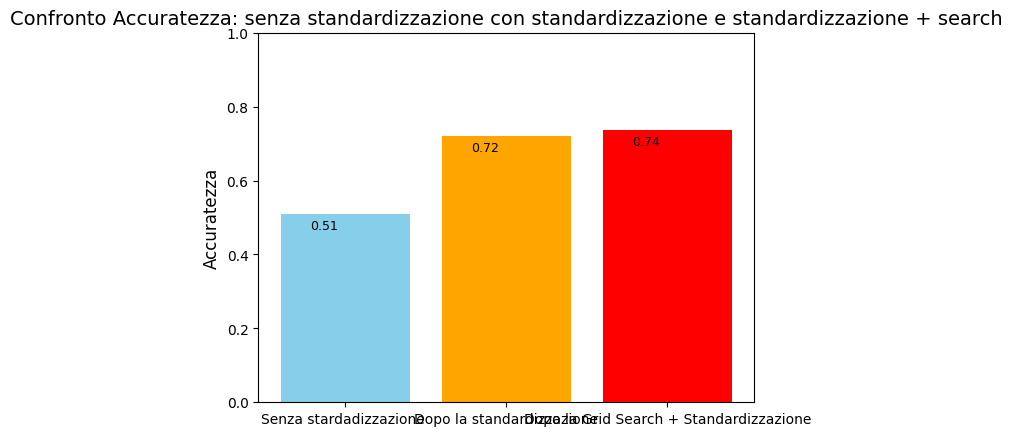

In [14]:
Grafico_Tre_Valori(before_standardization,after_standardization,logistic)